Importing Libraries

In [ ]:
# efficient storage of datasets, mathematical operations, combination of other libraries
import numpy as np
# image processing(reshaping,resizing)
import cv2
# files/directory management
import os
# plotting/data visualization
import seaborn as sns
# plotting 2d and 3d dimensions, histograms
import matplotlib.pyplot as plt
# processes/cleans out data, indexing data
import pandas as pd
from sklearn.model_selection import GridSearchCV

#Cancer Detection Using Images

Import/Extract Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

visualDataPath = "/content/drive/MyDrive/Datasets/Dataset_BUSI_with_GT 3"
numericalDataPath = "/content/drive/MyDrive/Datasets/breast-cancer.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Visual Data Preprocessing

Organizing Data File into Datasets

In [ ]:
benignImages = []
malignantImages = []
# Resizes images and appends it to the list, depending on whether the folder was malignant or benign
for folder in os.listdir(visualDataPath):
  if folder =="benign":
    benign_path = os.path.join(visualDataPath, folder)
    for image_name in os.listdir(benign_path):
      image_path = os.path.join(visualDataPath, folder, image_name)
      benignImage=cv2.imread(image_path)
      resized_img = cv2.resize(benignImage, (128,128), interpolation = cv2.INTER_AREA)
      benignImages.append(resized_img)

  if folder =="malignant":
    malignant_path = os.path.join(visualDataPath, folder)
    for image_name in os.listdir(malignant_path):
      image_path = os.path.join(visualDataPath, folder, image_name)
      malignantImage=cv2.imread(image_path)
      resized_img = cv2.resize(malignantImage, (128,128), interpolation = cv2.INTER_AREA)
      malignantImages.append(resized_img)

Slicing Length of Benign Images to Reduce Bias

In [ ]:
# malignant and benign image list lengths must be the same in the training data
benignImages=benignImages[:421]

NumPy Array Conversion

In [ ]:
# converting to NumPy arrays for easier use with other libraries
benign_images_list = [np.array(img) for img in benignImages]
malignant_images_list = [np.array(img) for img in malignantImages]
benignImagesNp = np.stack(benign_images_list)
malignantImagesNp = np.stack(malignant_images_list)

Labelling Data

In [ ]:
# 0 is benign, 1 is malignant=>so we know whether the image represents a malignant or benign tumor
benignImageLabels = np.array([0]*421)
malignantImageLabels = np.array([1]*421)
imageLabels = np.append(benignImageLabels,malignantImageLabels)

Combines benign images and malignant into one dataset

In [ ]:
# easier to train model with one dataset
images = np.append(benignImages,malignantImages,axis=0)

Normalizing Images

In [ ]:
# all pixel values are on the same scale now, making it easier for the model to disinguish the difference
# large input values may confuse the model
# each pixel contributes same amount on scale, so no other pixel can dominate the others, eliminating bias
def normalize_one_image(image):
  """This function takes in an image and returns the same image normalized on a 0 to 1 scale
   makes it easier for model to make connections"""
  return (image - np.min(image)) / (np.max(image) - np.min(image))

In [ ]:
# performs normalize_one_image funciton on every image in the list
normalizedImages = np.array([normalize_one_image(img) for img in images])

Converting Images to Grayscale

In [ ]:
# when all images are compared to on the color values, model can predict easier
from skimage import color
images = np.array([color.rgb2gray(image) for image in normalizedImages])

Declaring x and y values for the model to train

In [ ]:
X=images
y=imageLabels

In [ ]:
from sklearn.model_selection import train_test_split
# supervised learning
# the test size parameter indicates what percent of the dataset will be used as testing for the model and how much for training
# random state decides how to shuffle data
X_trainVisual, X_testVisual, y_trainVisual, y_testVisual = train_test_split(X, y, test_size=0.2, random_state=42)

Reshaping x and y

In [ ]:
X_trainVisual = X_trainVisual.reshape(673, 128*128)
X_testVisual = X_testVisual.reshape(169, 128*128)

##Image Model Development

CNN

In [ ]:
y_trainVisualOneHot = []
for label in y_trainVisual:
  if label ==0:
    y_trainVisualOneHot.append(np.array([1,0]))
  if label ==1:
    y_trainVisualOneHot.append(np.array([0,1]))
y_trainVisualOneHot = np.array(y_trainVisualOneHot)

y_testVisualOneHot = []
for label in y_testVisual:
  if label ==0:
    y_testVisualOneHot.append(np.array([1,0]))
  if label ==1:
    y_testVisualOneHot.append(np.array([0,1]))
y_testVisualOneHot = np.array(y_testVisualOneHot)

In [ ]:
# try this out
X_trainVisual3D = np.reshape(X_trainVisual3D, (-1, 128, 128, 3))
X_testVisual3D = np.reshape(X_testVisual3D, (-1, 128, 128, 3))

In [ ]:
X_trainVisual3D = X_trainVisual.reshape(len(X_trainVisual),128,128,1)
X_trainVisual3D = np.repeat(X_trainVisual3D,3,axis=-1)

X_testVisual3D = X_testVisual.reshape(len(X_testVisual),128,128,1)
X_testVisual3D = np.repeat(X_testVisual3D,3,axis=-1)

print(X_trainVisual3D.shape)
print(X_testVisual3D.shape)

(673, 128, 128, 3)
(169, 128, 128, 3)


In [ ]:
# # from sklearn.neighbors import KNeighborsClassifier
# # modelVisual=KNeighborsClassifier(n_neighbors=1)
# # modelVisual.fit(X_trainVisual, y_trainVisual)
# import keras.api._v2.keras as keras
# from keras.models import Sequential
# from keras.layers import Dense, Conv2D, InputLayer
# from keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape
# from sklearn.model_selection import StratifiedKFold
# from sklearn.model_selection import cross_val_score
# from tensorflow.keras import optimizers
# from keras.models import Sequential
# from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation
# from keras.optimizers import SGD
# from keras.callbacks import EarlyStopping

# cnn = Sequential()
# cnn.add(Conv2D(64, (3,3), input_shape=(128, 128, 3)))
# cnn.add(Activation('relu'))
# cnn.add(MaxPooling2D(pool_size=(2, 2)))
# cnn.add(Conv2D(32, (3,3)))
# cnn.add(Activation('relu'))
# cnn.add(Flatten())
# cnn.add(Dense(50, activation='relu'))
# cnn.add(Dense(2, activation='softmax'))

# opt = SGD(learning_rate=0.001, momentum=0.9)
# cnn.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# # early stopping to prevent overfitting
# early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# history = cnn.fit(X_trainVisual3D, y_trainVisualOneHot,
#                   validation_data=(X_testVisual3D, y_testVisualOneHot),
#                   epochs=10, batch_size=32,
#                   callbacks=[early_stopping])


In [ ]:
# Import necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Activation, MaxPooling2D, Dropout, Flatten, Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize CNN model
cnn = Sequential()
cnn.add(Conv2D(64, (3, 3), input_shape=(128, 128, 3)))  # Ensure input_shape matches your data
cnn.add(Activation('relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(32, (3, 3)))
cnn.add(Activation('relu'))
cnn.add(Flatten())
cnn.add(Dense(50, activation='relu'))
cnn.add(Dense(2, activation='softmax'))

# Set optimizer
opt = SGD(learning_rate=0.001, momentum=0.9)

# Compile model
cnn.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Fit model (ensure your training and testing data are correctly defined and preprocessed)
history = cnn.fit(X_trainVisual3D, y_trainVisualOneHot,
                  validation_data=(X_testVisual3D, y_testVisualOneHot),
                  epochs=10, batch_size=32,
                  callbacks=[early_stopping])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5397 - loss: 0.6902 - val_accuracy: 0.5148 - val_loss: 0.6775
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5499 - loss: 0.6783 - val_accuracy: 0.5444 - val_loss: 0.6683
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5701 - loss: 0.6717 - val_accuracy: 0.5976 - val_loss: 0.6527
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5919 - loss: 0.6529 - val_accuracy: 0.6746 - val_loss: 0.6424
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6588 - loss: 0.6343 - val_accuracy: 0.6036 - val_loss: 0.6402
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6536 - loss: 0.6268 - val_accuracy: 0.6509 - val_loss: 0.6200
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7126 - loss: 0.5917 - val_accuracy: 0.7278 - val_loss: 0.5825
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7339 - loss: 0.5664 - val_accuracy: 0.7574 - val_loss:

Numerical Data Preprocessing

In [ ]:
numericalData = pd.read_csv(numericalDataPath)

In [ ]:
# labelling data to 0 and 1 for benign and malignant=>supervised learning
diagnosisCol = numericalData["diagnosis"]
diagnosisNumerical = []
for d in diagnosisCol:
  if d =="B":
    diagnosisNumerical.append(0)
  if d =="M":
    diagnosisNumerical.append(1)
numericalData["diagnosisNumerical"]=diagnosisNumerical
numericalData.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosisNumerical'],
      dtype='object')

In [ ]:
# more benign data points than malignant will create bias
numericalData = numericalData.sort_values(by="diagnosisNumerical").tail(424)

Preprocessing Numerical Data/Cleaning out Unnecessary Columns

In [ ]:
# delete these values=>not much correlation, will only detriment the model=>more overlap
columns_to_drop = ['id', 'diagnosis', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se',
       'concavity_se', 'concave points_se', 'radius_worst', 'perimeter_worst',
       'area_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst']
numericalData = numericalData.drop(columns=columns_to_drop, errors='ignore')

#Numerical Data Model Development

Declaring X and y

In [ ]:
y = numericalData["diagnosisNumerical"]
X=numericalData[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']]

Splitting Data for Train and Test Data

In [ ]:
# x_train will train model, x_test will be used to test model's accuracy after model is built
X_trainNum, X_testNum, y_trainNum, y_testNum = train_test_split(X, y, test_size=0.2, random_state=42)

Decision Tree Numerical Data

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
modelNumerical = DecisionTreeClassifier(max_depth=2)
modelNumerical.fit(X_trainNum, y_trainNum)


DecisionTreeClassifier(max_depth=2)

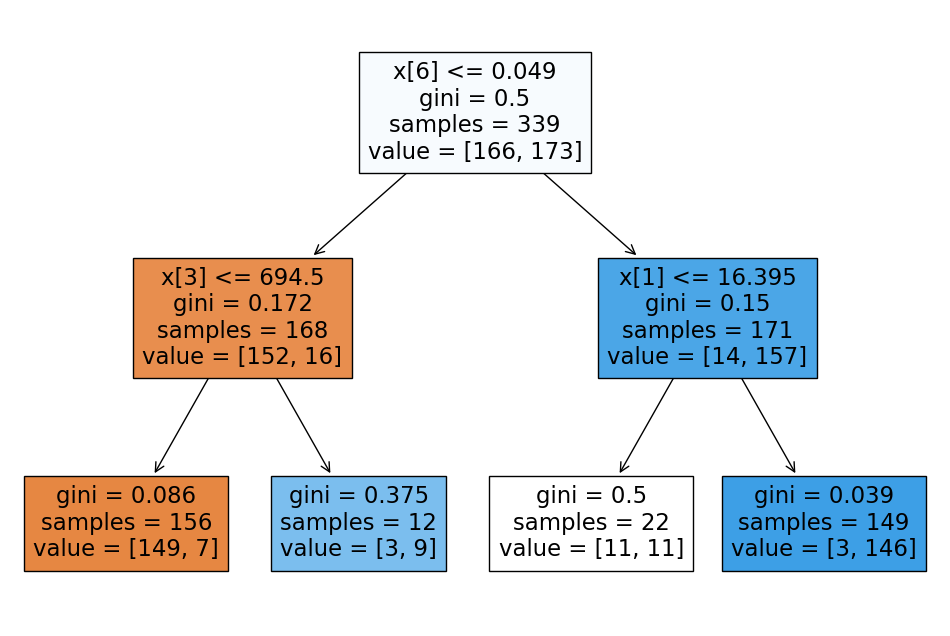

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(modelNumerical,filled=True)
plt.show()
#Shap, lime, pdp, shapley addictive explanations

Streamlit App Section

In [ ]:
!pip -q install pyngrok > /dev/null
!pip -q install streamlit > /dev/null
!pip -q install patool > /dev/null

In [ ]:
from joblib import dump, load
# if model imported from keras, write model.keras
dump(cnn, 'visualmodel.joblib')
dump(modelNumerical, 'nummodel.joblib')

['nummodel.joblib']

In [ ]:
%%writefile app.py
import streamlit as st
from joblib import dump, load
from skimage import color
import numpy as np
from PIL import Image
import cv2

# Load models
visualModel = load("visualmodel.joblib")
numModel = load("nummodel.joblib")

# Login functionality
def login():
    if 'logged_in' not in st.session_state:
        st.session_state.logged_in = False

    if not st.session_state.logged_in:
        username = st.sidebar.text_input("Username")
        password = st.sidebar.text_input("Password", type="password")
        if st.sidebar.button("Login"):
            if username == "your_username" and password == "your_password":
                st.session_state.logged_in = True
                st.sidebar.success("Logged in as {}".format(username))
            else:
                st.sidebar.error("Invalid credentials")

# Main function
def main():
    st.title("Breast Cancer Detection")

    # Login
    login()
    if st.session_state.logged_in:
      # Tabs
      tabs = ["Numerical Data", "Visual Data"]
      choice = st.sidebar.radio("Choose your option", tabs)

      # Numerical Data tab
      if choice == "Numerical Data":
          numerical_data()

      # Visual Data tab
      elif choice == "Visual Data":
          visual_data()

# Numerical Data function
def numerical_data():
    st.header("Numerical Data")
    numInputs=[]
    def getUserNumInput():
        radius_mean = st.number_input('What is the radius mean of the tumor?')
        texture_mean = st.number_input("What is the texture mean of the tumor?")
        perimeter_mean = st.number_input('What is the perimeter mean of the tumor?')
        area_mean = st.number_input("What is the area mean of the tumor?")
        compactness_mean = st.number_input('What is the compactness mean of the tumor?')
        concavity_mean = st.number_input("What is the concavity mean of the tumor?")
        concave_points_mean = st.number_input('What is the mean of the concave points of the tumor?')
        symmetry_mean = st.number_input('What is the symmetry mean of the tumor?')
        fractal_dimension_mean = st.number_input("What is the fractal dimension mean of the tumor?")
        numInputs = [[radius_mean,texture_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean]]
        return numInputs

    numericalDataInput = getUserNumInput()
    st.write(numericalDataInput)

    def numPredictions(numInputs):
      diagnosis = numModel.predict(numInputs)
      if diagnosis == 0:
        return "Benign Tumor"
      elif diagnosis == 1:
        return "Malignant Tumor"
      st.pyplot()
    numDiagnosis = numPredictions(numericalDataInput)
    st.write(numDiagnosis)

    if numericalDataInput[0][6]<=0.049:
      st.write("Concave points mean was less than 0.049")
      if numericalDataInput[0][1]<=16.396:
        st.write("Texture mean was less than 16.396")
        st.write("Your tumor is benign")
      if numericalDataInput[0][0]<=14.98:
        st.write("Radius mean was less than 14.98")
        st.write("Your tumor is benign")
    else:
      st.write("Your tumor is malignant")

# Visual Data function
def visual_data():
    st.header("Visual Data")

    def visPredictions(image):
        diagnosis = visualModel.predict(image)
        if diagnosis == 0:
          return "Benign Tumor"
        elif diagnosis == 1:
          return "Malignant Tumor"

    uploaded_file = st.file_uploader("Choose an image file", type=["png", "jpg"])

    if uploaded_file:
        uploaded_image = Image.open(uploaded_file)
        st.image(uploaded_image)
        uploaded_image = np.array(uploaded_image)
        uploaded_image = cv2.resize(uploaded_image, (128, 128), interpolation=cv2.INTER_AREA)
        uploaded_image = (uploaded_image - np.min(uploaded_image)) / (np.max(uploaded_image) - np.min(uploaded_image))
        uploaded_image = color.rgb2gray(uploaded_image)
        uploaded_image = uploaded_image.reshape(1, 128 * 128)
        st.write("Diagnosis:", visPredictions(uploaded_image))


if __name__ == "__main__":
    main()

#neigh_indndarray of shape (n_queries, n_neighbors)


Overwriting app.py


In [ ]:
!ngrok authtoken 2TltLE5lZuVaTG5IDh1Yae7Qhz0_2JgQ8URHsHS8UWvH9yXjV

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

def launch_website():
  print ("Click this link to try your web app:")
  if (ngrok.get_tunnels() != None):
    ngrok.kill()
  public_url = ngrok.connect()
  print(public_url)
  !streamlit run --server.port 80 app.py > /dev/null

In [ ]:
launch_website()

Click this link to try your web app:


ERROR:pyngrok.process.ngrok:t=2024-09-02T00:24:38+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/tunnels/agents\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2024-09-02T00:24:38+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/tunnels/agents\r\n\r\nERR_NGROK_108\r\n.